In [61]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob
import pickle
from collections import defaultdict
from pprint import pprint

In [56]:
import numpy as np

ha = data["human_action"]
print(ha.shape, ha.dtype)
print(np.unique(ha.argmax(axis=1), return_counts=True))


(7114, 6) int64
(array([0, 1]), array([7064,   50]))


In [62]:
file_dir = 'sub003-ses02-block2-game2/video_stat_000.npy'
#file_dir = 'thinker-20251128-113442-90400-0/video_stat.npy'
#file_dir = 'thinker-20251023-165530-327280-0/video_stat.npy'
#file_dir = 'test/spaceinvaders_9e6_1.npy'
data_dir = os.path.join('./test', file_dir)
data = (np.load(data_dir, allow_pickle=True)).item()
print('data.keys():', data.keys())
print('real image data length:', len(data['real_imgs']))
print('imagination image data length:', len(data['im_imgs']))

data.keys(): dict_keys(['real_imgs', 'im_imgs', 'actor_policy', 'reset_policy', 'status', 'tree_reps', 'env_return', 'cur_rewards', 'step_times', 'tree_reps_vector', 'human_action', 'thinker_action', 'real_vectors', 'im_vectors', 'im_vp_vectors'])
real image data length: 227291
imagination image data length: 227291


In [63]:
# data['status']에서 각 값의 개수 계산
status_values = [0, 1, 2, 3]  # 계산하려는 status 값들
status_counts = {}

for value in status_values:
    # 해당 값을 가진 인덱스의 개수 계산
    count = np.sum(np.array(data['status']) == value)
    status_counts[value] = count

# 결과 출력
for value, count in status_counts.items():
    status_name = {
        0: "실제 스텝(real step)",
        1: "리셋(reset)",
        2: "상상 스텝(imaginary step)",
        3: "강제 리셋(force reset)"
    }.get(value, "알 수 없음")
    
    print(f"Status {value} ({status_name}): {count}개")

# 특정 값(예: 0)을 가진 인덱스 목록 구하기
indices_with_value_1 = np.where(np.array(data['status']) == 1)[0]
print(f"\nStatus 1을 가진 인덱스의 개수: {len(indices_with_value_1)}")

Status 0 (실제 스텝(real step)): 3470개
Status 1 (리셋(reset)): 88043개
Status 2 (상상 스텝(imaginary step)): 135291개
Status 3 (강제 리셋(force reset)): 487개

Status 1을 가진 인덱스의 개수: 88043


In [64]:
def analyze_status_data(status_data):
    """
    status 데이터를 분석하여 real step과 imaginary step을 구분하고
    각 real step마다의 planning depth를 계산합니다.
    
    새로운 방식: 0부터 다음 0까지를 하나의 stage로 간주하되,
    그 사이에 1,3이 있으면 끊어서 계산하고, 각 구간의 길이들의 평균을 planning depth로 사용합니다.
    
    Args:
        status_data: status 값들의 배열 (0, 1, 2, 3 중 하나의 값)
    
    Returns:
        real_indices: real step의 인덱스들
        planning_depths: 각 real step마다의 planning depth 값 (평균값)
        reset_info: 리셋 정보 (각 imagination 구간에서 리셋이 발생한 위치)
    """
    real_indices = []
    planning_depths = []  # 각 real step마다의 planning depth 값 (평균값)
    reset_info = []
    
    i = 0
    while i < len(status_data):
        # status가 0인 real step 찾기
        if status_data[i] == 0:
            real_indices.append(i)
            
            # 다음 real step(status=0)까지의 imagination 구간 찾기
            imagination_start = i + 1
            imagination_end = len(status_data)  # 기본값: 끝까지
            
            # 다음 real step 찾기
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break
            
            # imagination 구간에서의 planning depth 계산 (새로운 방식)
            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                
                # 1과 3을 만나면 끊어서 각 구간의 길이 계산
                segment_lengths = []
                current_length = 0
                reset_positions = []
                
                for k, status_val in enumerate(imagination_segment):
                    if status_val in [1, 3]:  # 리셋 발생 (1 또는 3)
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:  # 상상 스텝 (2)
                        current_length += 1
                    # status_val == 0인 경우는 이미 처리됨
                
                # 마지막 구간 추가
                if current_length > 0:
                    segment_lengths.append(current_length)
                
                # planning depth는 각 구간의 길이들의 평균
                if segment_lengths:
                    avg_planning_depth = np.mean(segment_lengths)
                else:
                    avg_planning_depth = 0.0
                
                planning_depths.append(avg_planning_depth)
                
                reset_info.append({
                    'reset_positions': reset_positions,
                    'segment_lengths': segment_lengths,
                    'total_length': sum(segment_lengths),
                    'avg_planning_depth': avg_planning_depth
                })
            else:
                planning_depths.append(0.0)
                reset_info.append({
                    'reset_positions': [],
                    'segment_lengths': [],
                    'total_length': 0,
                    'avg_planning_depth': 0.0
                })
            
            i = imagination_end
        else:
            i += 1
    
    return real_indices, planning_depths, reset_info

# 데이터 로드 및 분석
status_data = data['status']
real_indices, imagination_lengths, reset_info = analyze_status_data(status_data)

def analyze_noop_planning_relationship(data, window_size=10, stride=2):
    """
    Sliding window를 사용하여 NOOP action 빈도와 planning depth의 관계를 분석합니다.
    status가 0인 real step 데이터만 분석 대상으로 합니다.
    
    Args:
        data: 로드된 데이터 딕셔너리
        window_size: sliding window 크기 (real step 기준)
        stride: sliding 간격 (real step 기준)
    
    Returns:
        window_results: 각 윈도우별 분석 결과
    """
    status_data = data['status']
    total_length = len(status_data)
    
    # status 데이터 분석 (planning depth 계산용) - 새로운 방식 사용
    real_indices, planning_depths, reset_info = analyze_status_data(status_data)
    
    # NOOP action 추출 (one-hot encoding 처리)
    noop_actions = []
    for idx in range(total_length):
        if idx < len(data['tree_reps']['cur_action']):
            action_onehot = data['tree_reps']['cur_action'][idx]
            action_idx = np.argmax(action_onehot)
            noop_actions.append(action_idx)
        else:
            noop_actions.append(-1)  # 데이터가 없는 경우
    
    noop_actions = np.array(noop_actions)
    
    # status가 0인 real step에서만 NOOP action 추출
    real_step_noop_actions = []
    for idx in real_indices:
        if idx < len(noop_actions):
            real_step_noop_actions.append(noop_actions[idx])
        else:
            real_step_noop_actions.append(-1)
    
    real_step_noop_actions = np.array(real_step_noop_actions)
    
    window_results = []
    
    # Real step 기준으로 sliding window 분석
    for start_idx in range(0, len(real_indices) - window_size + 1, stride):
        end_idx = start_idx + window_size
        
        # 현재 윈도우의 real step 인덱스들
        window_real_indices = real_indices[start_idx:end_idx]
        window_noop_actions = real_step_noop_actions[start_idx:end_idx]
        window_planning_depths = planning_depths[start_idx:end_idx]
        
        # 1. NOOP action 분석 (real step에서만)
        noop_count = np.sum(window_noop_actions == 0)  # NOOP = 0
        noop_frequency = noop_count / window_size
        
        # 2. Planning depth 분석 - 윈도우 내 모든 real step의 planning depth 평균
        avg_planning_depth = np.mean(window_planning_depths)
        
        # 3. 결과 저장
        window_result = {
            'window_start': start_idx,
            'window_end': end_idx,
            'real_step_indices': window_real_indices,
            'noop_count': noop_count,
            'noop_frequency': noop_frequency,
            'avg_planning_depth': avg_planning_depth,
            'planning_depths': window_planning_depths,
            'noop_actions': window_noop_actions
        }
        
        window_results.append(window_result)
    
    return window_results

# 데이터 로드 및 분석
status_data = data['status']
real_indices, planning_depths, reset_info = analyze_status_data(status_data)

print(f"총 데이터 길이: {len(status_data)}")
print(f"Real step 개수: {len(real_indices)}")

if planning_depths:
    print(f"Planning Depth 통계 (각 real step별 평균값):")
    print(f"  - 평균: {np.mean(planning_depths):.2f}")
    print(f"  - 중앙값: {np.median(planning_depths):.2f}")
    print(f"  - 최대값: {np.max(planning_depths):.2f}")
    print(f"  - 최소값: {np.min(planning_depths):.2f}")
    print(f"  - 표준편차: {np.std(planning_depths):.2f}")
else:
    print("Planning depth 데이터가 없습니다.")

# 각 real step마다의 구간 수 통계
segment_counts = [len(info['segment_lengths']) for info in reset_info]
print(f"\n각 real step마다의 구간 수 통계:")
print(f"  - 평균: {np.mean(segment_counts):.2f}")
print(f"  - 중앙값: {np.median(segment_counts):.2f}")
print(f"  - 최대값: {np.max(segment_counts)}")
print(f"  - 최소값: {np.min(segment_counts)}")
print(f"  - 표준편차: {np.std(segment_counts):.2f}")

# 예시 출력 (처음 몇 개 real step의 planning depth)
print(f"\n=== 예시: 처음 5개 real step의 planning depth ===")
for i in range(min(5, len(planning_depths))):
    print(f"Real step {i+1} (인덱스 {real_indices[i]}): "
          f"Planning Depth = {planning_depths[i]:.2f}, "
          f"구간들 = {reset_info[i]['segment_lengths']}")

총 데이터 길이: 227291
Real step 개수: 3470
Planning Depth 통계 (각 real step별 평균값):
  - 평균: 1.77
  - 중앙값: 1.50
  - 최대값: 13.00
  - 최소값: 0.00
  - 표준편차: 0.84

각 real step마다의 구간 수 통계:
  - 평균: 24.66
  - 중앙값: 26.00
  - 최대값: 39
  - 최소값: 0
  - 표준편차: 6.60

=== 예시: 처음 5개 real step의 planning depth ===
Real step 1 (인덱스 0): Planning Depth = 1.26, 구간들 = [1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 4, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Real step 2 (인덱스 70): Planning Depth = 1.05, 구간들 = [1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Real step 3 (인덱스 148): Planning Depth = 1.22, 구간들 = [5, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1]
Real step 4 (인덱스 221): Planning Depth = 1.56, 구간들 = [10, 2, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]
Real step 5 (인덱스 287): Planning Depth = 1.26, 구간들 = [4, 4, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from openTSNE import TSNE, affinity, initialization

# ActorNet concat 우선순위
ACTOR_ORDER = [
    "last_pri", "last_reset", "last_reward",
    "tree_reps_vector", "tree_reps",   # tree_reps alias 지원
    "h_vectors", "im_vectors", "real_vectors",
    "im_vp_vectors", "im_imgs",
]

action_mapping = {
    "NOOP": 0, "FIRE": 1, "RIGHT": 2, "LEFT": 3, "RIGHTFIRE": 4, "LEFTFIRE": 5
}
idx_to_action = {v: k for k, v in action_mapping.items()}


def _normalize_specs(specs):
    if specs is None:
        return []
    if isinstance(specs, str):
        return [specs]
    return list(specs)


def _order_specs_by_actor(specs):
    present = set(specs)
    ordered = [k for k in ACTOR_ORDER if k in present]
    ordered.extend([k for k in specs if k not in ordered])
    return ordered


def _flatten(arr, max_len=None):
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        arr = arr[:, None]
    else:
        arr = arr.reshape(arr.shape[0], -1)
    return arr.astype(np.float32)


def _concat_dict_values(d):
    parts = [np.asarray(v) for v in d.values()]
    if not parts:
        raise ValueError("dict feature에 값이 없습니다.")
    common_len = min(p.shape[0] for p in parts)
    flat_parts = [_flatten(p, common_len) for p in parts]
    return np.concatenate(flat_parts, axis=1)


def _feature_from_key(data, key):
    # tree_reps / tree_reps_vector는 동일 처리
    if key in ("tree_reps_vector", "tree_reps"):
        if "tree_reps" not in data or not isinstance(data["tree_reps"], dict):
            raise KeyError("'tree_reps' dict가 data에 없습니다.")
        return _concat_dict_values(data["tree_reps"])

    if key not in data:
        raise KeyError(f"'{key}'가 data에 없습니다.")

    value = data[key]
    if isinstance(value, dict):
        return _concat_dict_values(value)

    return _flatten(value)


def vectorize_by_specs(data, specs):
    entries = []
    for key in specs:
        try:
            entries.append(_feature_from_key(data, key))
        except KeyError:
            # 없는 key는 건너뜀
            continue

    if not entries:
        raise ValueError("선택된 feature가 없습니다.")

    common_len = min(e.shape[0] for e in entries)
    entries = [e[:common_len] for e in entries]
    return np.concatenate(entries, axis=1), common_len


def pair_planning_before_real(status):
    status = np.asarray(status)
    real_idx = np.where(status == 0)[0]
    driver_idx = real_idx - 1
    mask = driver_idx >= 0
    return real_idx[mask], driver_idx[mask]


def _decode_label_array(arr):
    arr = np.asarray(arr)

    # one-hot or logits [T, A]
    if arr.ndim == 2:
        ids = np.argmax(arr, axis=1)
        return np.array([idx_to_action.get(int(i), f"A{int(i)}") for i in ids], dtype=object)

    # class id [T]
    if arr.ndim == 1 and np.issubdtype(arr.dtype, np.integer):
        return np.array([idx_to_action.get(int(i), f"A{int(i)}") for i in arr], dtype=object)

    # fallback: 문자열/기타
    return arr.astype(object)


def _extract_labels(data, label_specs, max_len, real_idx):
    label_keys = _normalize_specs(label_specs)
    if not label_keys:
        raise ValueError("label_specs를 최소 1개 지정해야 합니다. 예: 'human_action'")

    parts = []
    for key in label_keys:
        if key not in data:
            raise KeyError(f"label key '{key}'가 data에 없습니다.")
        labels_all = _decode_label_array(data[key])[:max_len]
        parts.append(labels_all[real_idx].astype(str))

    if len(parts) == 1:
        return parts[0]

    # 여러 label을 합쳐 하나의 hue로 사용
    return np.array([" | ".join(x) for x in zip(*parts)], dtype=object)


def prepare_feature_matrix(data, feature_specs=None, label_specs="human_action"):
    specs = _normalize_specs(feature_specs)
    specs = _order_specs_by_actor(specs)
    feature_matrix, max_len = vectorize_by_specs(data, specs)

    status = np.asarray(data["status"])[:max_len]
    real_idx, driver_idx = pair_planning_before_real(status)

    feature_subset = feature_matrix[driver_idx]
    labels = _extract_labels(data, label_specs, max_len, real_idx)

    # planning depth 표시(선택적)
    if "analyze_status_data" in globals():
        all_real_idx, depths, _ = analyze_status_data(status)
        depth_map = {idx: depth for idx, depth in zip(all_real_idx, depths)}
        planning_depths = np.array([depth_map.get(idx, np.nan) for idx in real_idx])
    else:
        planning_depths = np.full(real_idx.shape, np.nan)

    return feature_subset, labels, planning_depths, driver_idx, real_idx


def fit_tsne_opentsne(feature_matrix, perplexity=35, random_state=0, pca_dim=50):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)

    pca_k = min(pca_dim, scaled.shape[1], scaled.shape[0] - 1)
    if pca_k < 2:
        raise ValueError("PCA 차원을 만들 수 없습니다. 샘플 수/특징 수를 확인하세요.")

    pca = PCA(n_components=pca_k, random_state=random_state)
    reduced = pca.fit_transform(scaled)

    base = max(5, int(perplexity))
    perps = sorted({base, max(base * 5, base + 1)})

    aff = affinity.Multiscale(
        reduced,
        perplexities=perps,
        method="approx",
        metric="euclidean",
        n_jobs=-1,
        random_state=random_state,
    )
    init = initialization.pca(reduced, random_state=random_state)
    tsne = TSNE(
        n_components=2,
        n_jobs=-1,
        negative_gradient_method="fft",
        early_exaggeration_iter=250,
        early_exaggeration=12,
        n_iter=750,
        random_state=random_state,
    )
    emb = tsne.fit(affinities=aff, initialization=init)

    if len(perps) > 1:
        aff.set_perplexities([float(min(perps))])
        emb = emb.optimize(n_iter=250, exaggeration=1, momentum=0.8)

    return np.asarray(emb)


def _load_single_npy(path):
    obj = np.load(path, allow_pickle=True)

    # np.save(dict) 케이스
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.shape == ():
        data = obj.item()
        if isinstance(data, dict):
            return data

    # npz 케이스
    if hasattr(obj, "files"):
        return {k: obj[k] for k in obj.files}

    raise ValueError(f"{path}: dict 형태의 npy/npz를 해석할 수 없습니다.")


def _normalize_datasets(data=None, npy_files=None):
    datasets = []

    if npy_files is not None:
        files = _normalize_specs(npy_files)
        for p in files:
            datasets.append((str(p), _load_single_npy(p)))
        return datasets

    if data is None:
        raise ValueError("data 또는 npy_files 중 하나는 반드시 지정해야 합니다.")

    if isinstance(data, dict):
        return [("in_memory_0", data)]

    if isinstance(data, (list, tuple)):
        for i, d in enumerate(data):
            if not isinstance(d, dict):
                raise ValueError("data 리스트는 dict 원소들로 구성되어야 합니다.")
            datasets.append((f"in_memory_{i}", d))
        return datasets

    raise ValueError("data 형식이 올바르지 않습니다. (dict 또는 dict 리스트)")


def plot_tsne(
    data=None,
    npy_files=None,
    feature_specs=None,
    label_specs="human_action",  # 예: "human_action" 또는 "thinker_action" 또는 ["human_action","thinker_action"]
    perplexity=35,
    random_state=0,
    pca_dim=50,
):
    datasets = _normalize_datasets(data=data, npy_files=npy_files)

    all_feats = []
    all_labels = []
    all_depths = []
    all_driver_idx = []
    all_real_idx = []
    all_source_name = []

    for source_name, one_data in datasets:
        feats, labels, depths, driver_idx, real_idx = prepare_feature_matrix(
            one_data,
            feature_specs=feature_specs,
            label_specs=label_specs,
        )
        all_feats.append(feats)
        all_labels.append(labels)
        all_depths.append(depths)
        all_driver_idx.append(driver_idx)
        all_real_idx.append(real_idx)
        all_source_name.append(np.array([source_name] * feats.shape[0], dtype=object))

    feature_matrix = np.concatenate(all_feats, axis=0)
    label_values = np.concatenate(all_labels, axis=0)
    planning_depths = np.concatenate(all_depths, axis=0)
    source_names = np.concatenate(all_source_name, axis=0)

    if feature_matrix.shape[0] <= perplexity:
        raise ValueError("perplexity는 전체 샘플 수보다 작아야 합니다.")

    emb = fit_tsne_opentsne(
        feature_matrix,
        perplexity=perplexity,
        random_state=random_state,
        pca_dim=pca_dim,
    )

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        x=emb[:, 0],
        y=emb[:, 1],
        hue=label_values,
        palette="tab10",
        alpha=0.8,
        edgecolor="none",
    )
    plt.title("t-SNE (actor-order concat, openTSNE)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

    return {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "label": label_values,
        "planning_depth": planning_depths,
        "source_file": source_names,
        # 파일별 local index를 그대로 보관
        "driver_idx_local": all_driver_idx,
        "action_idx_local": all_real_idx,
    }


In [ ]:
# 여러 npy/npz 파일을 한 번에 합쳐서 t-SNE
tsne_results_multi = plot_tsne(
    npy_files=[
        "test/sub001/ses-04/sub001-ses04-block2-game2_000.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_001.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_002.npy",
        "test/sub001/ses-04/sub001-ses04-block2-game2_003.npy",
    ],
    feature_specs=["tree_reps"],
    label_specs="human_action",  # 또는 ["human_action", "thinker_action"]
    perplexity=30,
    random_state=0,
    pca_dim=50
)

SyntaxError: unmatched ')' (4124871866.py, line 15)

In [2]:
"""Utilities for visualizing behavioral embeddings across checkpoints.

These helpers iterate over every ``.npy`` file inside a folder, extract the
planning snapshot that immediately precedes each real action (status==0), and
render t‑SNE plots where each real action inherits the hue (action id) and
training step brightness.  The pairing logic works for tree_reps, real_imgs,
real_vectors, etc., so you can compare multiple targets in one run.
"""

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union, Sequence as SeqLike

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------------
# Shared constants/helpers
# ---------------------------------------------------------------------------

ACTION_MAPPING = {
    "NOOP": 0,
    "FIRE": 1,
    "RIGHT": 2,
    "LEFT": 3,
    "RIGHTFIRE": 4,
    "LEFTFIRE": 5,
}
IDX_TO_ACTION = {v: k for k, v in ACTION_MAPPING.items()}

TRAINING_STEP_IN_NAME = re.compile(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", re.IGNORECASE)
TRAINING_STEP_IN_DIR = re.compile(r"(\d+(?:e\d+)?)$", re.IGNORECASE)
ALL_FIELD_SENTINELS = {"tree_reps", "all", "ALL", "*"}
EXCLUDED_TREE_REP_FIELDS = {}


def _format_training_step(step: float) -> str:
    if step >= 1_000_000:
        return f"{step/1_000_000:.1f}M"
    if step >= 1_000:
        return f"{step/1_000:.1f}K"
    return f"{int(step)}"


# ---------------------------------------------------------------------------
# Status / pairing utilities
# ---------------------------------------------------------------------------

def analyze_status_data(status_data: Sequence[int]) -> Tuple[List[int], List[float], List[dict]]:
    real_indices: List[int] = []
    planning_depths: List[float] = []
    reset_info: List[dict] = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths: List[int] = []
                current_length = 0
                reset_positions: List[int] = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_planning_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_planning_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_planning_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data: Sequence[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    status_arr = np.asarray(status_data)
    real_indices, planning_depths_forward, _ = analyze_status_data(status_arr)

    paired_real: List[int] = []
    planning_indices: List[int] = []
    paired_depths: List[float] = []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_indices.append(cand)
        paired_depths.append(planning_depths_forward[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_indices, dtype=np.int64),
        np.asarray(paired_depths, dtype=np.float32),
    )


def _normalize_tree_fields(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]]
) -> List[str]:
    if tree_fields is None:
        return [
            k
            for k, v in tree_reps.items()
            if isinstance(v, np.ndarray) and k not in EXCLUDED_TREE_REP_FIELDS
        ]

    if isinstance(tree_fields, str):
        if tree_fields in ALL_FIELD_SENTINELS:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]

    filtered_fields = [f for f in tree_fields if f not in ALL_FIELD_SENTINELS]
    filtered_fields = [f for f in filtered_fields if f not in EXCLUDED_TREE_REP_FIELDS]
    if not filtered_fields:
        return _normalize_tree_fields(tree_reps, None)

    resolved = []
    missing = []
    for field in filtered_fields:
        if field in tree_reps:
            resolved.append(field)
        else:
            missing.append(field)

    if missing:
        raise KeyError(f"Missing tree_rep fields: {missing}")

    return resolved


def vectorize_tree_reps(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]] = None
) -> Tuple[np.ndarray, int]:
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [tree_reps[k].shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))

    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr: np.ndarray, max_len: Optional[int] = None) -> Tuple[np.ndarray, int]:
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(
    data: dict,
    source: str = "tree_reps",
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)

    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    if source == "tree_reps":
        matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)
    else:
        if source not in data:
            raise KeyError(f"Source '{source}' not present in data keys: {list(data.keys())}")
        limit = min(len(data[source]), len(status_data))
        matrix, common_len = _flatten_step_array(data[source], max_len=limit)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    root_len = root_action_full.shape[0]

    valid = (planning_indices < common_len) & (real_indices < root_len)
    if not np.any(valid):
        raise ValueError(f"No valid indices remain after aligning '{source}' with status array.")

    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    features = matrix[planning_indices]
    action_ids = np.argmax(root_action_full[real_indices], axis=1)

    return features, action_ids, planning_depths, real_indices, planning_indices


# ---------------------------------------------------------------------------
# Dataset aggregation
# ---------------------------------------------------------------------------

def extract_training_step(path_like: Union[str, os.PathLike]) -> int:
    path = Path(path_like)
    name_match = TRAINING_STEP_IN_NAME.search(path.name)
    if name_match:
        token = name_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    dir_match = TRAINING_STEP_IN_DIR.search(path.parent.name)
    if dir_match:
        token = dir_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    for part in reversed(path.parent.parts):
        if part.startswith("thinker-"):
            chunks = part.split("-")
            for chunk in reversed(chunks):
                if chunk.isdigit() or TRAINING_STEP_IN_DIR.match(chunk or ""):
                    try:
                        return int(float(chunk))
                    except ValueError:
                        continue
    return 0


def build_tree_rep_dataset(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    max_files: Optional[int] = None,
    stride: int = 1,
    logger=print,
) -> dict:
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found under {folder}")

    all_vectors: List[np.ndarray] = []
    all_actions: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    all_planning: List[np.ndarray] = []
    all_steps: List[np.ndarray] = []
    all_sources: List[np.ndarray] = []
    all_real_idx: List[np.ndarray] = []
    all_plan_idx: List[np.ndarray] = []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to load {npy_path.name}: {exc}")
            continue

        try:
            (
                tree_real,
                action_ids,
                planning_depths,
                real_indices,
                planning_indices,
            ) = prepare_real_step_matrix(
                data, source=source, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            tree_real = tree_real[::stride]
            action_ids = action_ids[::stride]
            planning_depths = planning_depths[::stride]
            real_indices = real_indices[::stride]
            planning_indices = planning_indices[::stride]

        if tree_real.size == 0:
            continue

        training_step = extract_training_step(npy_path)
        step_arr = np.full(tree_real.shape[0], training_step, dtype=np.int64)
        source_arr = np.array([npy_path.name] * tree_real.shape[0])
        action_labels = np.vectorize(lambda a: IDX_TO_ACTION.get(int(a), f"A{int(a)}"))(action_ids)

        all_vectors.append(tree_real)
        all_actions.append(action_ids)
        all_labels.append(action_labels)
        all_planning.append(planning_depths)
        all_steps.append(step_arr)
        all_sources.append(source_arr)
        all_real_idx.append(real_indices.astype(np.int64))
        all_plan_idx.append(planning_indices.astype(np.int64))

        if logger:
            logger(
                f"[loaded] {npy_path.name:<35s} "
                f"pairs={tree_real.shape[0]:5d}  step={_format_training_step(training_step)}  source={source}"
            )

    if not all_vectors:
        raise RuntimeError(f"No usable tree_reps found under {folder}.")

    def _stack(chunks: List[np.ndarray]) -> np.ndarray:
        return np.concatenate(chunks, axis=0)

    dataset = {
        "tree_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "action_labels": _stack(all_labels),
        "planning_depths": _stack(all_planning),
        "training_steps": _stack(all_steps),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }

    return dataset


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------

def _mix_with_white(color: Union[str, Sequence[float]], strength: float) -> Tuple[float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(color))
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(rgb * (1.0 - strength) + strength)


def _compute_point_colors(action_ids: np.ndarray, training_steps: np.ndarray) -> Tuple[List[Tuple[float, float, float]], dict]:
    unique_actions = sorted(np.unique(action_ids))
    base_palette = sns.color_palette("tab10", n_colors=max(10, len(unique_actions)))
    base_color_map = {
        action: base_palette[action % len(base_palette)] for action in unique_actions
    }

    min_step = float(training_steps.min())
    max_step = float(training_steps.max())
    if math.isclose(min_step, max_step):
        norm = np.zeros_like(training_steps, dtype=float)
    else:
        norm = (training_steps - min_step) / (max_step - min_step)
    strengths = 0.15 + 0.7 * norm

    colors = []
    for action_id, strength in zip(action_ids, strengths):
        base = base_color_map[action_id]
        colors.append(_mix_with_white(base, float(strength)))

    return colors, base_color_map


def fit_tsne(tree_matrix: np.ndarray, perplexity: int = 30, random_state: int = 0) -> np.ndarray:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(tree_matrix)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=2000,
        verbose=1,
    )
    return tsne.fit_transform(scaled)


def plot_tree_rep_tsne_for_folder(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    perplexity: int = 35,
    random_state: int = 0,
    stride: int = 1,
    max_files: Optional[int] = None,
) -> dict:
    dataset = build_tree_rep_dataset(
        root_folder=root_folder,
        tree_fields=tree_fields,
        source=source,
        max_files=max_files,
        stride=stride,
    )
    emb = fit_tsne(dataset["tree_matrix"], perplexity=perplexity, random_state=random_state)
    colors_with_brightness, base_color_map = _compute_point_colors(
        dataset["action_ids"], dataset["training_steps"]
    )
    pure_colors = [base_color_map[a] for a in dataset["action_ids"]]

    if source == "tree_reps":
        if tree_fields is None:
            fields_label = "all fields"
        elif isinstance(tree_fields, (list, tuple)):
            fields_label = " + ".join(tree_fields)
        else:
            fields_label = str(tree_fields)
        title_suffix = f" ({fields_label})"
    else:
        title_suffix = ""

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    axes[0].scatter(emb[:, 0], emb[:, 1], c=colors_with_brightness, s=18, linewidths=0, alpha=0.95)
    axes[0].set_title(f"t-SNE [{source}]{title_suffix}\nHue = action, brightness = training step")
    axes[0].set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")

    axes[1].scatter(emb[:, 0], emb[:, 1], c=pure_colors, s=18, linewidths=0, alpha=0.95)
    axes[1].set_title(f"t-SNE [{source}] (no brightness)\nHue = action only")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    action_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=base_color_map[action], label=f"{IDX_TO_ACTION.get(action, action)} ({action})")
        for action in sorted(base_color_map)
    ]
    legend_actions = axes[0].legend(
        handles=action_handles,
        title="Action (base hue)",
        loc="upper right",
        bbox_to_anchor=(1.32, 1.0),
    )
    axes[0].add_artist(legend_actions)

    unique_steps = np.unique(dataset["training_steps"])
    sample_steps = unique_steps
    if unique_steps.size > 5:
        quantiles = np.linspace(0.0, 1.0, num=5)
        sample_steps = np.unique(np.round(np.quantile(unique_steps, quantiles)).astype(int))

    def _strength_for_step(step_val: float) -> float:
        min_step = float(unique_steps.min())
        max_step = float(unique_steps.max())
        if math.isclose(min_step, max_step):
            return 0.35
        norm = (step_val - min_step) / (max_step - min_step)
        return 0.15 + 0.7 * norm

    step_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=_mix_with_white("black", _strength_for_step(step)),
            label=_format_training_step(float(step)),
        )
        for step in sample_steps
    ]
    axes[0].legend(
        handles=step_handles,
        title="Training step\n(brightness only)",
        loc="lower right",
        bbox_to_anchor=(1.32, 0.0),
    )

    plt.tight_layout()
    plt.show()

    tsne_table = {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "action_id": dataset["action_ids"],
        "action_label": dataset["action_labels"],
        "training_step": dataset["training_steps"],
        "planning_depth": dataset["planning_depths"],
        "source_file": dataset["source_files"],
        "real_index": dataset["real_indices"],
        "planning_index": dataset["planning_indices"],
    }

    return tsne_table



def plot_multiple_tsne_targets(
    root_folder: Union[str, os.PathLike],
    configs: Optional[Sequence[dict]] = None,
    shared_kwargs: Optional[dict] = None,
) -> dict:
    shared_kwargs = dict(shared_kwargs) if shared_kwargs else {}
    if configs is None:
        configs = [
            {"name": "tree_reps", "source": "tree_reps"},
            {"name": "real_imgs", "source": "real_imgs"},
            {"name": "real_vectors", "source": "real_vectors"},
        ]

    results = {}
    for cfg in configs:
        cfg = cfg.copy()
        name = cfg.pop("name", cfg.get("source", "tree_reps"))
        print("=" * 80)
        print(f"[t-SNE] {name}")
        local_kwargs = {**shared_kwargs, **cfg}
        results[name] = plot_tree_rep_tsne_for_folder(
            root_folder=root_folder,
            **local_kwargs,
        )

    return results




유효 real step 수: 102
평균 planning depth: 1.31, 평균 total time: 0.111


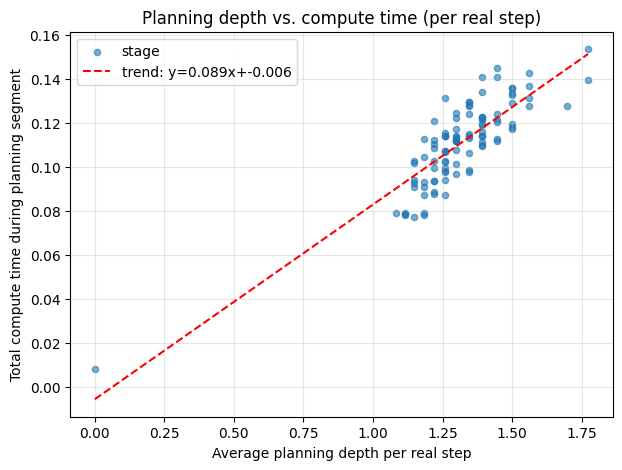

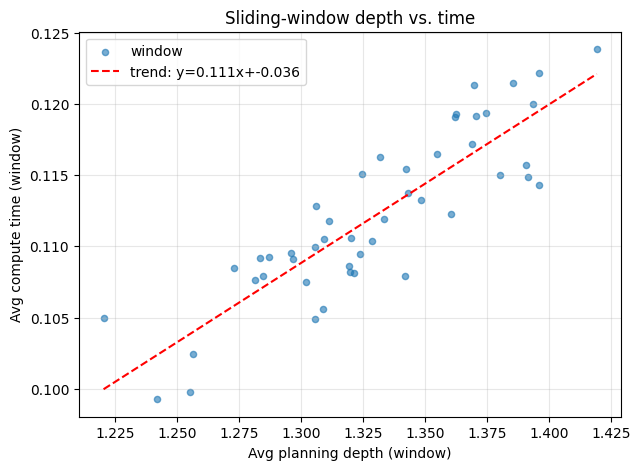

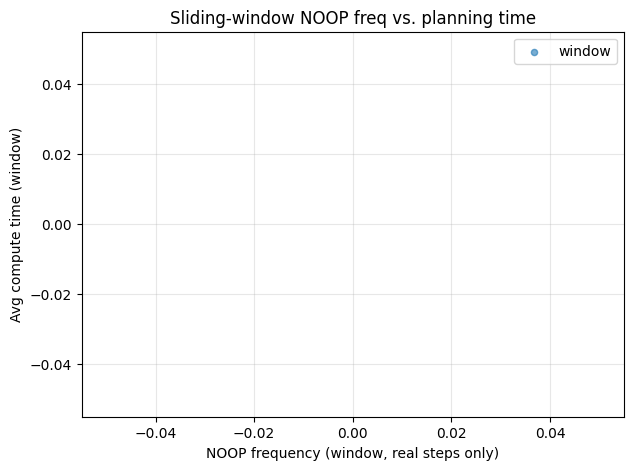

Linear projection correlation (R): 0.7948
Coefficient of determination (R^2): 0.6317


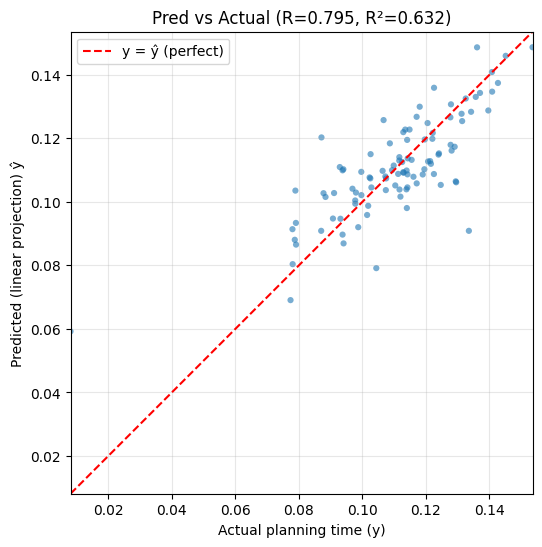

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# ==== helper: tree_reps flatten ====
def flatten_tree_reps(tree_reps):
    parts = [np.asarray(v) for v in tree_reps.values()]
    common_len = min(p.shape[0] for p in parts)
    parts = [p[:common_len].reshape(common_len, -1) for p in parts]
    return np.concatenate(parts, axis=1), common_len

# ==== 1) per-real-step planning depth & compute time ====
def compute_depth_time(data):
    status = np.asarray(data["status"])
    step_times = np.asarray(data.get("step_times"), dtype=float)

    min_len = min(len(status), len(step_times))
    status = status[:min_len]
    step_times = step_times[:min_len]

    real_idx, planning_depths, reset_info = analyze_status_data(status)

    segment_times = []
    for i, start in enumerate(real_idx):
        end = real_idx[i + 1] if i + 1 < len(real_idx) else len(status)
        seg_time = np.nansum(step_times[start:end])
        segment_times.append(seg_time)

    return np.array(real_idx), np.array(planning_depths, dtype=float), np.array(segment_times, dtype=float)

real_idx, planning_depths, segment_times = compute_depth_time(data)

mask = np.isfinite(planning_depths) & np.isfinite(segment_times)
pd_clean = planning_depths[mask]
st_clean = segment_times[mask]
print(f"유효 real step 수: {len(pd_clean)}")
print(f"평균 planning depth: {pd_clean.mean():.2f}, 평균 total time: {st_clean.mean():.3f}")

plt.figure(figsize=(7,5))
plt.scatter(pd_clean, st_clean, alpha=0.6, s=20, label="stage")
if len(pd_clean) > 1:
    coef = np.polyfit(pd_clean, st_clean, 1)
    x_line = np.linspace(pd_clean.min(), pd_clean.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Average planning depth per real step")
plt.ylabel("Total compute time during planning segment")
plt.title("Planning depth vs. compute time (per real step)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 2) Sliding window로 depth/time 관계 ====
def sliding_window_stats(values, times, window_size=10, stride=2):
    vals = np.asarray(values)
    tms = np.asarray(times)
    results = []
    for start in range(0, len(vals) - window_size + 1, stride):
        end = start + window_size
        win_vals = vals[start:end]
        win_tms = tms[start:end]
        results.append({
            "start": start,
            "end": end,
            "avg_depth": np.nanmean(win_vals),
            "avg_time": np.nanmean(win_tms),
        })
    return results

win_stats = sliding_window_stats(pd_clean, st_clean, window_size=10, stride=2)
win_depth = np.array([w["avg_depth"] for w in win_stats])
win_time = np.array([w["avg_time"] for w in win_stats])

plt.figure(figsize=(7,5))
plt.scatter(win_depth, win_time, alpha=0.6, s=20, label="window")
if len(win_depth) > 1:
    coef = np.polyfit(win_depth, win_time, 1)
    x_line = np.linspace(win_depth.min(), win_depth.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Avg planning depth (window)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window depth vs. time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 3) Sliding window로 NOOP 빈도 vs. planning time ====
noop_actions = []
cur_action = data["tree_reps"]["cur_action"]  # one-hot 가정
for i in range(len(real_idx)):
    idx = real_idx[i]
    if idx < len(cur_action):
        onehot = cur_action[idx]
        noop_actions.append(int(np.argmax(onehot)))
    else:
        noop_actions.append(-1)
noop_actions = np.array(noop_actions)

noop_clean = noop_actions[mask]

win_noop_freq = []
win_time2 = []
window_size = 150
stride = 2
for start in range(0, len(noop_clean) - window_size + 1, stride):
    end = start + window_size
    win_noop = noop_clean[start:end]
    win_tms = st_clean[start:end]
    valid = win_noop != -1
    if valid.any():
        freq = np.sum(win_noop[valid] == 0) / np.sum(valid)
    else:
        freq = np.nan
    win_noop_freq.append(freq)
    win_time2.append(np.nanmean(win_tms))
win_noop_freq = np.array(win_noop_freq)
win_time2 = np.array(win_time2)

plt.figure(figsize=(7,5))
plt.scatter(win_noop_freq, win_time2, alpha=0.6, s=20, label="window")
valid = np.isfinite(win_noop_freq) & np.isfinite(win_time2)
if valid.sum() > 1:
    coef = np.polyfit(win_noop_freq[valid], win_time2[valid], 1)
    x_line = np.linspace(win_noop_freq[valid].min(), win_noop_freq[valid].max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("NOOP frequency (window, real steps only)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window NOOP freq vs. planning time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 4) tree_reps_vector vs planning time: linear projection & multiple correlation ====
tree_matrix, common_len = flatten_tree_reps(data["tree_reps"])
driver_idx = real_idx - 1
valid = (driver_idx >= 0) & (driver_idx < common_len) & np.isfinite(segment_times)
X = tree_matrix[driver_idx[valid]]
y = segment_times[valid]

# 스케일링 후 선형회귀
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
reg = LinearRegression().fit(X_scaled, y)
y_hat = reg.predict(X_scaled)

# multiple correlation (corr of y_hat vs y) 및 R^2
R = np.corrcoef(y_hat, y)[0, 1]
R2 = reg.score(X_scaled, y)
print(f"Linear projection correlation (R): {R:.4f}")
print(f"Coefficient of determination (R^2): {R2:.4f}")

# y_hat, y가 위에서 계산된 상태라고 가정
plt.figure(figsize=(6,6))
plt.scatter(y, y_hat, alpha=0.6, s=20, edgecolor="none")
lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
plt.plot(lims, lims, 'r--', label="y = ŷ (perfect)")
plt.xlabel("Actual planning time (y)")
plt.ylabel("Predicted (linear projection) ŷ")
plt.title(f"Pred vs Actual (R={R:.3f}, R²={R2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


In [ ]:
import numpy as np
#data = np.load('/home/jmme425/thinker/behavioral_data_block/sub_1/game_2/day_1/block_3/sub1-game2-day1-block3-block-27192.npz')
data = np.load('/home/jmme425/thinker/behavioral_data_block/sub-001/ses-04/sub001-ses04-block2-game2.npz')
term_idx = np.flatnonzero(data["is_first"])
term_idx2 = np.flatnonzero(data["is_terminal"])
print(term_idx)
print("start count:", term_idx.size)
print(term_idx2)
print("end count:", term_idx2.size)